<a href="https://colab.research.google.com/github/iasolb/ECON3916-Statistics-MachineLearning/blob/main/Lab11/Lab11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# !pip install category_encoders

import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce

# Step 1: Ingestion from external source
url = 'https://raw.githubusercontent.com/iasolb/reference_data/refs/heads/main/messy_hr_economics.csv'
df = pd.read_csv(url)

df.head(1)

,employee_id,department_raw,department,office_zip,tenure_years,age,year_hired,regional_unemployment,regional_cpi_inflation,performance_rating,bonus_pay,base_salary,retention_risk
0,E100000,Sls,Sales,91586,2.3,27,2024,4.3,3.54,3.0,3571.89,64113.01,0.275


# Step 2: Visual Forensics
__________



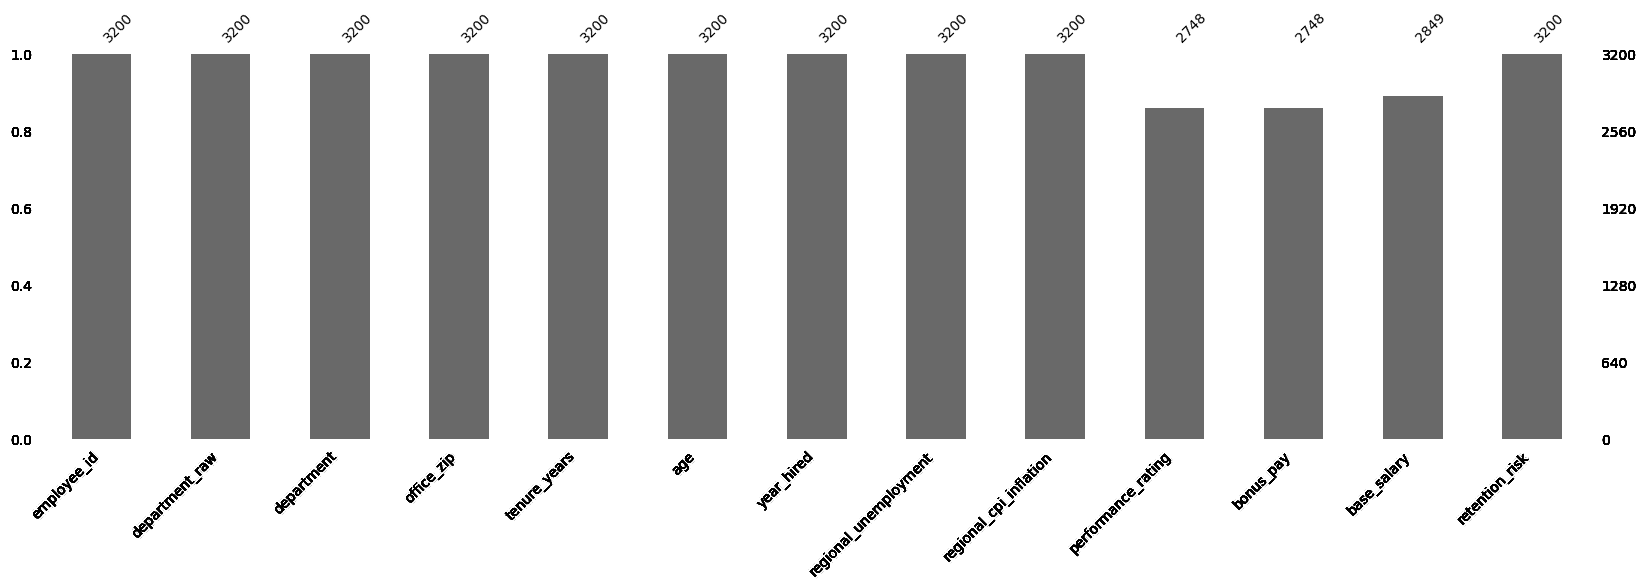

In [10]:
# Instructor Note: Students should visually observe that missing 'bonus_pay'
# perfectly aligns with missing 'performance_rating'.
# This structural alignment indicates MAR (Missing at Random).


for col in df.columns:
    msno.bar(df,
             figsize=(20,5),
             fontsize=10)

# Step 3: Grouped Conditional Imputation
# Imputing the median salary based on department to preserve variance structures

In [11]:
df['base_salary'] = df.groupby('department')['base_salary'].transform(lambda x: x.fillna(x.median()))

# Step 4: The Dummy Variable Trap (Intentional Failure)

In [12]:
# Generate binary dummy columns for the department categories without dropping the first category.
# Add a constant intercept and watch the Ordinary Least Squares (OLS) algorithm fail due to singular matrices and perfect linear dependence.


dummies_trap = pd.get_dummies(df['department'], drop_first=False).astype(int)
X_trap = pd.concat([df[['tenure_years']], dummies_trap], axis=1)

# Adding the constant intercept creates perfect multicollinearity
X_trap = sm.add_constant(X_trap)
y = df['base_salary']

# This will trigger a severe multicollinearity warning or a LinAlgError
model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:04:37   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.765e+04    244.020    236.246   

# Step 5: Escaping the Trap (k-1 methodology)

In [13]:

# drop_first=True establishes the reference category
dummies_safe = pd.get_dummies(df['department'], drop_first=True).astype(int)
X_safe = pd.concat([df[['tenure_years']], dummies_safe], axis=1)
X_safe = sm.add_constant(X_safe)
model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

# Step 5b: Target Encoding High Cardinality
# Condensing 800 ZIP codes into a single continuous vector representing average salary
encoder = ce.TargetEncoder(cols=['office_zip'])
df['zip_encoded'] = encoder.fit_transform(df['office_zip'], df['base_salary'])

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:05:07   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         9.527e+04    372.412    255.807   